# Resolução comentada — Base Iris com medidas de distância e K-means

Este notebook foi preparado para alunos de graduação e mostra, passo a passo, como:

1. carregar a base Iris;
2. normalizar os dados;
3. calcular a matriz de distâncias;
4. aplicar o algoritmo K-means com $k=3$;
5. visualizar os clusters;
6. comparar os clusters com as espécies reais.

A ideia não é apenas executar o código, mas entender **o que cada linha faz** e **por que ela está sendo usada**.


## Etapa 1 — Importação das bibliotecas

Nesta etapa, importamos as bibliotecas necessárias para trabalhar com a base de dados, normalização, cálculo de distâncias, agrupamento e visualização.


In [1]:
# Importa a função load_iris, que carrega a base Iris pronta do scikit-learn
from sklearn.datasets import load_iris

# Importa o MinMaxScaler, usado para re-escalar os dados no intervalo [0,1]
from sklearn.preprocessing import MinMaxScaler

# Importa o algoritmo KMeans, que será usado para fazer o agrupamento
from sklearn.cluster import KMeans

# Importa uma função para calcular distâncias entre todos os pares de objetos
from sklearn.metrics import pairwise_distances

# Importa o pandas para manipular dados em formato de tabela
import pandas as pd

# Importa o matplotlib para gerar gráficos
import matplotlib.pyplot as plt


## Etapa 2 — Carregando a base Iris

A base Iris possui:

- 150 amostras;
- 4 atributos numéricos;
- 3 espécies de flores.

Ela é uma das bases mais utilizadas no ensino de mineração de dados e aprendizado de máquina.


In [2]:
# Carrega a base Iris em memória
iris = load_iris()

# Converte os atributos numéricos em um DataFrame do pandas
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adiciona a espécie real como uma nova coluna
df['species'] = iris.target

# Mostra as cinco primeiras linhas da tabela
print('Base original:')
display(df.head())


Base original:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Interpretação

A coluna `species` representa a classe real da flor:

- 0 = Setosa
- 1 = Versicolor
- 2 = Virginica

Essa coluna **não será usada no agrupamento**, pois clustering é uma tarefa **não supervisionada**. Porém, ela será usada no fim para comparar o resultado do K-means com as espécies reais.


## Etapa 3 — Normalizando os dados

Como o K-means usa distância, é importante colocar os atributos em uma escala comparável.

Aqui utilizamos a **re-escala min-max**, que transforma os valores para o intervalo $[0,1]$:

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$


In [4]:
# Cria o objeto responsável pela normalização
scaler = MinMaxScaler()

# Seleciona apenas as quatro colunas numéricas e aplica a normalização
df_norm = scaler.fit_transform(df.iloc[:, 0:4])

# Mostra os primeiros registros já normalizados
print('Dados normalizados:')
print(df_norm[:5])


Dados normalizados:
[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


### Interpretação

Todos os atributos agora estão entre 0 e 1. Isso evita que um atributo com escala maior domine os demais no cálculo da distância.


## Etapa 4 — Calculando a matriz de distâncias

Agora vamos calcular a **matriz de distâncias Euclidianas** entre todos os pares de flores.

A distância Euclidiana entre dois vetores $x$ e $y$ é dada por:

$$
d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

Como a base tem 150 flores, a matriz resultante terá dimensão **150 × 150**.


In [5]:
# Calcula a matriz de distâncias usando a métrica Euclidiana
dist_matrix = pairwise_distances(df_norm, metric='euclidean')

# Converte para DataFrame apenas para facilitar a visualização
dist_df = pd.DataFrame(dist_matrix)

# Mostra um trecho da matriz
print('Trecho da matriz de distâncias:')
display(dist_df.iloc[:5, :5])


Trecho da matriz de distâncias:


,0,1,2,3,4
0,0.000000,0.215614,0.168101,0.217612,0.050077
1,0.215614,0.000000,0.101578,0.094699,0.251538
2,0.168101,0.101578,0.000000,0.060472,0.187108
3,0.217612,0.094699,0.060472,0.000000,0.236719
4,0.050077,0.251538,0.187108,0.236719,0.000000


### O que observar?

- A diagonal principal é zero, pois a distância de um objeto para ele mesmo é zero.
- A matriz é simétrica: a distância de A para B é a mesma de B para A.


## Etapa 5 — Aplicando o K-means

Agora vamos aplicar o algoritmo K-means com **3 clusters**, pois a base Iris possui 3 espécies conhecidas.

Parâmetros escolhidos:

- `n_clusters=3`: número de grupos;
- `n_init=10`: tenta 10 inicializações e escolhe a melhor;
- `random_state=42`: garante reprodutibilidade.


In [8]:
# Cria o modelo K-means
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)

# Ajusta o modelo aos dados normalizados e obtém o cluster de cada flor
clusters = kmeans.fit_predict(df_norm)

# Adiciona o cluster encontrado ao DataFrame original
df['cluster'] = clusters

# Mostra as primeiras linhas com os clusters
print('Base com clusters:')
display(df.head())

display(df)


Base com clusters:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,2
146,6.3,2.5,5.0,1.9,2,1
147,6.5,3.0,5.2,2.0,2,2
148,6.2,3.4,5.4,2.3,2,2


### Interpretação

Cada flor recebeu um rótulo de cluster. Esses rótulos não são as espécies reais; eles representam apenas os grupos encontrados automaticamente pelo K-means.


## Etapa 6 — Comparando clusters com espécies reais

Como a base Iris já possui a espécie correta, podemos comparar o agrupamento encontrado com as classes reais.


In [9]:
# Cria uma tabela de contingência entre espécie real e cluster encontrado
comparacao = pd.crosstab(df['species'], df['cluster'])

print('Comparação entre espécie real e cluster encontrado:')
display(comparacao)


Comparação entre espécie real e cluster encontrado:


cluster,0,1,2
species,,,
0,50,0,0
1,0,47,3
2,0,14,36


### Como interpretar?

Se o agrupamento estiver muito bom, esperamos que cada espécie fique concentrada em um cluster.

Na base Iris, normalmente acontece o seguinte:

- Setosa é muito bem separada;
- Versicolor e Virginica tendem a se misturar parcialmente.

Isso acontece porque Setosa tem pétalas muito diferentes das demais, enquanto Versicolor e Virginica apresentam sobreposição em parte do espaço de atributos.


## Etapa 7 — Visualização dos clusters

Agora vamos gerar um gráfico de dispersão usando duas variáveis bastante informativas:

- comprimento da pétala;
- largura da pétala.

Essas variáveis costumam separar bem as espécies da Iris.


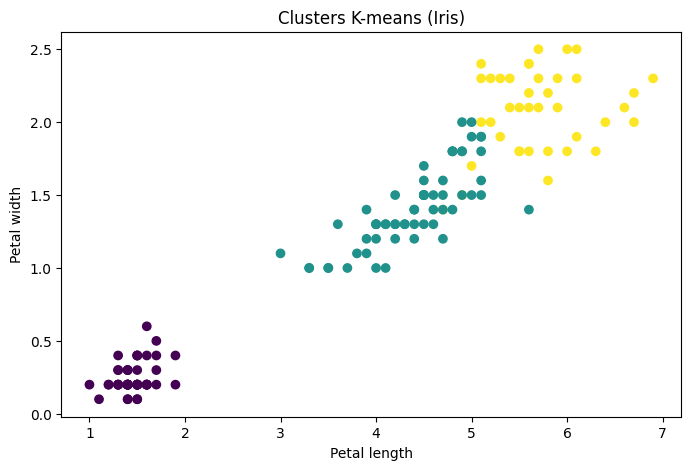

In [ ]:
# Cria o gráfico de dispersão colorido pelo cluster
plt.figure(figsize=(8, 5))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['cluster']) 
plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('Clusters K-means (Iris)')
plt.show()


### Interpretação

Visualmente, normalmente veremos:

- um grupo bem separado, correspondente à Setosa;
- dois grupos com alguma interseção, correspondentes a Versicolor e Virginica.


## Etapa 8 — Resposta analítica do desafio

Os clusters encontrados pelo algoritmo K-means fazem sentido **parcialmente** quando comparados com as espécies reais da base Iris.

A espécie **Setosa** costuma ser perfeitamente separada, formando um cluster bem definido, pois possui características bastante distintas, principalmente em relação às pétalas.

Por outro lado, **Versicolor** e **Virginica** costumam apresentar sobreposição, o que faz com que alguns exemplos sejam misturados nos clusters. Isso ocorre porque o K-means utiliza distância Euclidiana e tende a funcionar melhor em grupos mais compactos e aproximadamente esféricos.

Portanto:

- o clustering encontrou padrões coerentes;
- mas não reproduziu perfeitamente as classes reais;
- o que é esperado em uma tarefa não supervisionada.


## Desafios extras para os alunos

1. O que acontece se o K-means for executado **sem normalização**?
2. O que muda se `n_clusters` for igual a 2 ou 4?
3. Como fica a visualização se você trocar os atributos do gráfico?
4. Compare os resultados do K-means com um algoritmo como **DBSCAN**.
5. Tente colorir o gráfico pela espécie real em vez do cluster e compare os dois resultados.


Comparação SEM normalização:
cluster_sem_norm   0   1   2
species                     
0                  0  50   0
1                 48   0   2
2                 14   0  36


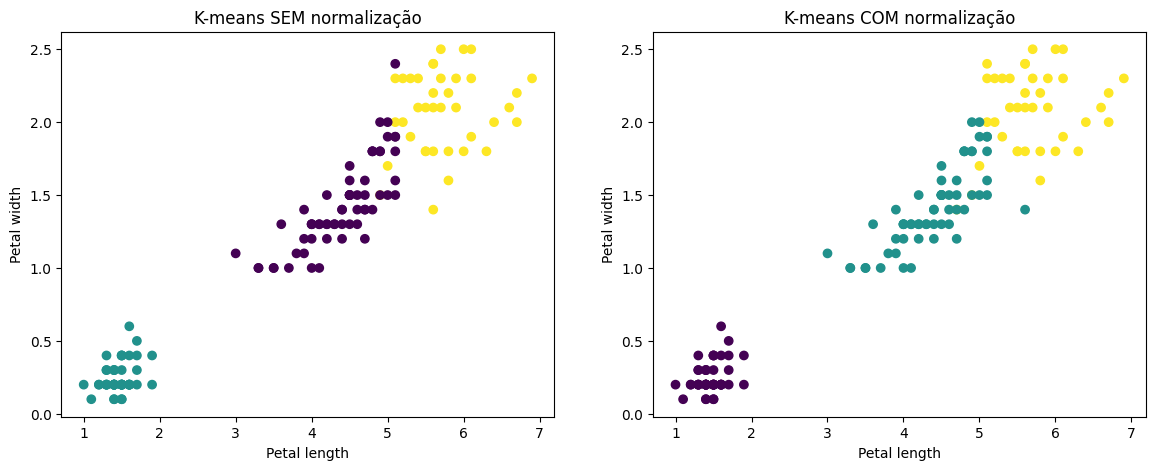

In [ ]:
# Espaço livre para experimentos dos alunos

# 1. O que acontece se o K-means for executado **sem normalização**?
# clusters sem normalização  estarão menos bem definidos, 
# pois atributos com escalas maiores alteram os centróides e prejudicam a separação dos grupos.


# K-means direto, sem normalização
kmeans_sem_norm = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters_sem_norm = kmeans_sem_norm.fit_predict(df.iloc[:, 0:4])  

df['cluster_sem_norm'] = clusters_sem_norm

# comparações
print("Comparação SEM normalização:")
print(pd.crosstab(df['species'], df['cluster_sem_norm']))

# visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df['petal length (cm)'], df['petal width (cm)'], 
            c=df['cluster_sem_norm'])
ax1.set_title('K-means SEM normalização')
ax1.set_xlabel('Petal length')
ax1.set_ylabel('Petal width')

ax2.scatter(df['petal length (cm)'], df['petal width (cm)'], 
            c=df['cluster'])
ax2.set_title('K-means COM normalização')
ax2.set_xlabel('Petal length')
ax2.set_ylabel('Petal width')
plt.show()

In [30]:
# 2. O que muda se `n_clusters` for igual a 2 ou 4?

# Como há 3 especies conhecidas, ele irá misturar alguma das espécias a outra, criando dois grupos
#  com n-cluster igual a 4, haverá a divisão de uma das espécias em 2



# 2. O que muda se n_clusters for igual a 2 ou 4?

for k in [2, 3, 4]:
    kmeans_k = KMeans(n_clusters=k, n_init=10, random_state=42)
    clusters_k = kmeans_k.fit_predict(df_norm)
    
    print(f"\n=== K-MEANS com k={k} ===")
    print(pd.crosstab(df['species'], clusters_k))


=== K-MEANS com k=2 ===
col_0     0   1
species        
0         0  50
1        50   0
2        50   0

=== K-MEANS com k=3 ===
col_0     0   1   2
species            
0        50   0   0
1         0  47   3
2         0  14  36

=== K-MEANS com k=4 ===
col_0     0   1   2   3
species                
0        50   0   0   0
1         0   0  27  23
2         0  29   2  19


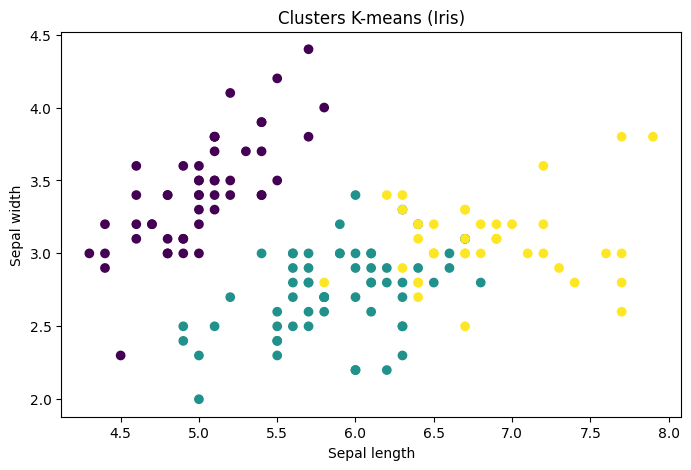

In [32]:
# 3. Como fica a visualização se você trocar os atributos do gráfico?

# Alguns pares de atributos separam bem as espécies, enquanto outros não.

plt.figure(figsize=(8, 5))
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['cluster']) 
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Clusters K-means (Iris)')
plt.show()



=== K-MEANS ===
Clusters: 3
Ruído: 0

=== DBSCAN (eps=0.2) ===
Clusters: 2
Ruído: 22

=== K-MEANS × ESPÉCIES ===
cluster   0   1   2
species            
0        50   0   0
1         0  47   3
2         0  14  36

=== DBSCAN × ESPÉCIES ===
cluster_dbscan  -1   0   1
species                   
0                3  47   0
1                5   0  45
2               14   0  36


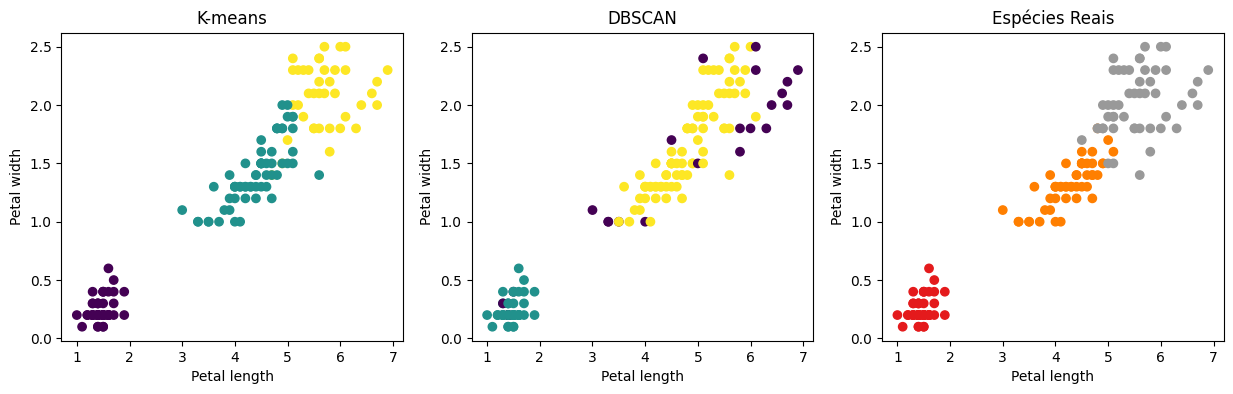

In [ ]:
# 4. Compare os resultados do K-means com um algoritmo como DBSCAN

from sklearn.cluster import DBSCAN

# raio igual a 0,15 e vizinhos = 5
dbscan = DBSCAN(eps=0.15, min_samples=5)
clusters_dbscan = dbscan.fit_predict(df_norm)
df['cluster_dbscan'] = clusters_dbscan

# contagem de clusters e ruído
n_clusters_db = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

# resumo
print("=== K-MEANS ===")
print("Clusters: 3")
print("Ruído: 0")

print("\n=== DBSCAN (eps=0.2) ===")
print(f"Clusters: {n_clusters_db}")
print(f"Ruído: {n_noise}")

# Comparação com espécies reais
print("\n=== K-MEANS × ESPÉCIES ===")
print(pd.crosstab(df['species'], df['cluster']))

print("\n=== DBSCAN × ESPÉCIES ===")
print(pd.crosstab(df['species'], df['cluster_dbscan']))

# gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['cluster'])
axes[0].set_title('K-means')
axes[0].set_xlabel('Petal length')
axes[0].set_ylabel('Petal width')

axes[1].scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['cluster_dbscan'])
axes[1].set_title('DBSCAN')
axes[1].set_xlabel('Petal length')
axes[1].set_ylabel('Petal width')

axes[2].scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['species'], cmap='Set1')
axes[2].set_title('Espécies Reais')
axes[2].set_xlabel('Petal length')
axes[2].set_ylabel('Petal width')

plt.show()